import necessary libraries

In [4]:
import pandas as pd
import numpy as np

Load raw dataset

In [5]:
file = r"C:\Users\Lenovo\OneDrive\Documents\DataSprint\data\DataWave.csv"

df = pd.read_csv(file)


Inspect dataset


In [6]:
df.isnull().sum()

df.info()
df.describe()
df.head()
df.tail()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       695 non-null    object 
 1   country                       705 non-null    object 
 2   age                           705 non-null    int64  
 3   gender                        626 non-null    object 
 4   subscription_type             705 non-null    object 
 5   avg_listening_hours_per_week  705 non-null    float64
 6   total_songs_played            705 non-null    int64  
 7   skip_rate                     705 non-null    object 
 8   satisfaction_score            661 non-null    float64
 9   churned                       705 non-null    object 
 10  monthly_fee                   672 non-null    object 
 11  join_date                     705 non-null    object 
dtypes: float64(2), int64(2), object(8)
memory usage: 66.2+ KB


Index(['user_id', 'country', 'age', 'gender', 'subscription_type',
       'avg_listening_hours_per_week', 'total_songs_played', 'skip_rate',
       'satisfaction_score', 'churned', 'monthly_fee', 'join_date'],
      dtype='object')

cleaning user_id

In [7]:
df['user_id'].isnull().sum()
df = df.drop_duplicates(subset=['user_id'])

df= df.dropna(subset=['user_id'])


Convert all categorical text column to lower case and strip whitespaces. These are for the rows of each their respective columns. Ensure column is treated as text with the help of .astype(str).

In [8]:
cat_cols = ['country', 'gender', 'subscription_type', 'churned']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

Cleaning gender values

In [9]:
df['gender'] = df['gender'].replace({
    'm': 'male',
    'f': 'female',
    'femle' : 'female',
    'female ': 'female',
    'others': 'other',
    'other ': 'other',
    'prefer not to say': 'unknown',
    'nan': np.nan
})

Cleaning churned columns. Convert yes/no or text to 0/1 integer  [user left => 1, user stayed => 0]

In [10]:
mapping = {
    'yes': 1, 'y': 1, '1': 1, 'true': 1,
    'no': 0, 'n': 0, '0': 0, 'false': 0
}

df['churned'] = (
    df['churned']
    .astype(str).str.strip().str.lower()
    .map(mapping)
)


# df['churned'].mean()   # Finding the mean of churned

Cleaning(Fix) Subscription Type

In [11]:
df['subscription_type'] = df['subscription_type'].replace({
    'premuim': 'premium',
    'premum': 'premium',
    'free trial': 'free',
    'fam': 'family',
    'stud': 'student',
    'studnt': 'student'
})

Cleaning country

In [12]:
df['country'] = df['country'].replace({
    'u.k.': 'United kingdom',
    'uk': 'United Kingdom',
    'U.K': ' United Kingdom',
    'united kingdom': 'United Kingdom',
    'United kingdom': 'United Kingdom',
    'ind': 'India',
    'india': 'India',
    'usa': 'United States',
    'us': 'United States',
    'nepal': 'Nepal',
    'nigeria': 'Nigeria',
    'ghana': 'Ghana',
    'kenya': 'Kenya',
    'brazil': 'Brazil',
    'south africa': 'South Africa'
})

Clean numeric columns. Convert invalid text like "ten" to NaN

In [13]:
num_cols = ['age', 'avg_listening_hours_per_week', 'total_songs_played', 'skip_rate', 'satisfaction_score', 'monthly_fee']

for cols in num_cols:
    df[cols] = pd.to_numeric(df[cols], errors='coerce')   # convert invalid values to NaN)

CLEAN join_date. Convert to datetime.

In [14]:
df['join_date'] = pd.to_datetime(df['join_date'], format='%m/%d/%Y', errors='coerce')
# df['join_date'].isnull().sum()

Checking Missing values

In [15]:
# df.isnull().sum()

IMPUTE MISSING VALUES PROPERLY [Fill in the missing data in the correct or appropriate way.]
1. Gender (leave as NaN or fill with "unknown"). [fillna means to fill in missing values]

In [16]:
df['gender'] = df['gender'].fillna('unknown')

2. When analyzing the skip rate, it's important to use the median rather than the mean. This is because the skip rate data is often skewed, meaning it can have outliers that disproportionately affect the average. The median provides a more accurate representation of the typical skip rate in such cases.

In [17]:
df['skip_rate'] = df['skip_rate'].fillna(df["skip_rate"].median())

3. Fill missing monthly fee values using the median value specific to each subscription type not the overall median.

In [18]:
df['monthly_fee'] = (
    df.groupby('subscription_type')['monthly_fee'].transform(lambda x: x.fillna(x.median()))
    )

4. Fill missing values for join_date

In [19]:
df['join_date'] = df['join_date'].fillna(df['join_date'].mode()[0])

Remove or fix numeric outliers:
1. skip_rate must be between 0 and 1 

In [20]:
df = df[(df['skip_rate'] >= 0) & (df['skip_rate'] <= 1)]

2. Age should be between 10 and 100

In [21]:
df = df[(df['age'] >= 10) & (df['age'] <= 100)]

3. Max listening hours per week = 168 (24*7)

In [22]:
df = df[df['avg_listening_hours_per_week'] <= 168]   

4. Satisfaction must be between 1 and 10

In [23]:
df = df[(df['satisfaction_score'] >= 1) & (df['satisfaction_score'] <= 10)]

5. Songs played cannot be negative + cap unrealistic values

In [24]:
df = df[df['total_songs_played'] >= 0]
df = df[df['total_songs_played'] < df['total_songs_played'].quantile(0.999)]

6.  Monthly fee cannot be negative or extremely high

In [25]:
df = df[df['monthly_fee'] >= 0]
df = df[df['monthly_fee'] < df['monthly_fee'].quantile(0.999)]

Reset index after removing rows

In [26]:
df = df.reset_index(drop=True)

FINAL MISSING VALUE CHECK

In [27]:
print("Final missing values:")
print(df.isnull().sum())
print(df.describe())
print(df.info())

Final missing values:
user_id                         0
country                         0
age                             0
gender                          0
subscription_type               0
avg_listening_hours_per_week    0
total_songs_played              0
skip_rate                       0
satisfaction_score              0
churned                         0
monthly_fee                     0
join_date                       0
dtype: int64
              age  avg_listening_hours_per_week  total_songs_played  \
count  581.000000                    581.000000          581.000000   
mean    38.407917                     10.204647          499.304647   
min     13.000000                      0.100000          440.000000   
25%     25.000000                      6.800000          484.000000   
50%     38.000000                     10.200000          499.000000   
75%     51.000000                     13.300000          514.000000   
max     64.000000                     23.700000          566

cleaned dataset

In [28]:
cleaned_dataset = r"C:\Users\Lenovo\OneDrive\Documents\DataSprint\data\cleaned_DataWave.csv"
df.to_csv(cleaned_dataset, index=False)

df = pd.read_csv(cleaned_dataset)

UNIVARIATE ANALYSIS (Single Variable at a Time)
1. Weekly listening hours distribution [Summary statistics of average listening hours per week]

In [29]:
df['avg_listening_hours_per_week'].describe() 

count    581.000000
mean      10.204647
std        4.838402
min        0.100000
25%        6.800000
50%       10.200000
75%       13.300000
max       23.700000
Name: avg_listening_hours_per_week, dtype: float64

2. Satisfaction Score Description

In [30]:
df['satisfaction_score'].describe()

count    581.000000
mean       3.141136
std        1.186437
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: satisfaction_score, dtype: float64

3. Counting the number of each subscription type

In [31]:
df['subscription_type'].value_counts()   

subscription_type
family     180
student    163
premium    152
free        86
Name: count, dtype: int64

4. Counting the number of each country

In [32]:
df['country'].value_counts()

country
United Kingdom    109
India              96
United States      68
Kenya              55
Nigeria            53
Ghana              50
South Africa       46
Brazil             36
Nepal              34
United kingdom     34
Name: count, dtype: int64

5. Counting the number of each country

In [33]:
df['gender'].value_counts()

gender
female     222
male       221
unknown     69
other       69
Name: count, dtype: int64

Relationship insights [Analysis part] [BIVARIATE ANALYSIS (Two Variables Relationship)]
1. Does churn differ by subscription type?(Churn rate by subscription type)

In [34]:
df.groupby('subscription_type')['churned'].mean().sort_values(ascending=False)

subscription_type
family     0.316667
premium    0.296053
student    0.294479
free       0.279070
Name: churned, dtype: float64

2. Do heavy listeners churn less? (Listening hours: churned vs active). Low hours = more churn, High hours = more engagement

In [35]:
df.groupby('churned')['avg_listening_hours_per_week'].mean()

churned
0    10.266093
1    10.060920
Name: avg_listening_hours_per_week, dtype: float64

3. Does satisfaction predict churn?(Satisfaction score: churned vs active). If churned users have lower scores then obvious red flag for company. 


In [36]:
df.groupby('churned')['satisfaction_score'].mean()

churned
0    3.110565
1    3.212644
Name: satisfaction_score, dtype: float64

4. Which country or region has highest churn? (Top 10 countries with highest churn)

In [37]:
df.groupby('country')['churned'].mean().sort_values(ascending=False).head(10)

country
Brazil            0.361111
Nigeria           0.358491
Ghana             0.340000
Kenya             0.327273
United Kingdom    0.321101
South Africa      0.304348
United kingdom    0.294118
India             0.260417
United States     0.235294
Nepal             0.205882
Name: churned, dtype: float64

5. Satisfaction by subscription type

In [38]:
df.groupby('subscription_type')['satisfaction_score'].mean().sort_values()

subscription_type
free       3.069767
student    3.098160
family     3.155556
premium    3.210526
Name: satisfaction_score, dtype: float64

6. Average listening hours by subscription type

In [39]:
df.groupby('subscription_type')['avg_listening_hours_per_week'].mean().sort_values()

subscription_type
family      9.943333
free       10.027907
premium    10.071711
student    10.710429
Name: avg_listening_hours_per_week, dtype: float64

7. Churn rate by age group.
pd.cut takes a continuous variable (like age) and splits it into buckets (bins).
EG:-
age_group
(10, 20]     0.08
(20, 30]     0.12
(30, 40]     0.15
(40, 50]     0.09
(50, 60]     0.07
(60, 100]    0.20
Name: churned, dtype: float64


In [40]:
df['age_group'] = pd.cut(df['age'], bins=[10,20,30,40,50,60,100])
df.groupby('age_group', observed=False)['churned'].mean()


age_group
(10, 20]     0.284211
(20, 30]     0.349057
(30, 40]     0.309735
(40, 50]     0.252101
(50, 60]     0.333333
(60, 100]    0.244898
Name: churned, dtype: float64

8. Engagement vs churn (songs played)

In [41]:
df.groupby('churned')['total_songs_played'].mean()

churned
0    498.855037
1    500.356322
Name: total_songs_played, dtype: float64

[MULTIVARIATE ANALYSIS (3 or More Variables Together)]

1. Correlation between numeric columns (to see drivers of churn). 

Correlation means How Two Things Move Together.
Imagine two things: X and Y (like age and monthly_charges).
Correlation tells you: When X goes up, does Y tend to go up as well? Or go down? Or not change in any clear way?

+1 → Perfect positive correlation, –1 → Perfect negative correlation, 0 → No clear linear relationship

For eg:-
It checks correlation between:-
Correlation between churned and age
Correlation between churned and monthly charges

In [42]:
df.corr(numeric_only=True)['churned'].sort_values(ascending=False)

churned                         1.000000
satisfaction_score              0.039442
total_songs_played              0.029878
monthly_fee                    -0.011022
avg_listening_hours_per_week   -0.019440
age                            -0.027391
skip_rate                      -0.066314
Name: churned, dtype: float64

Visualization
1. Visualize churn rate by subscription type

<Axes: xlabel='subscription_type'>

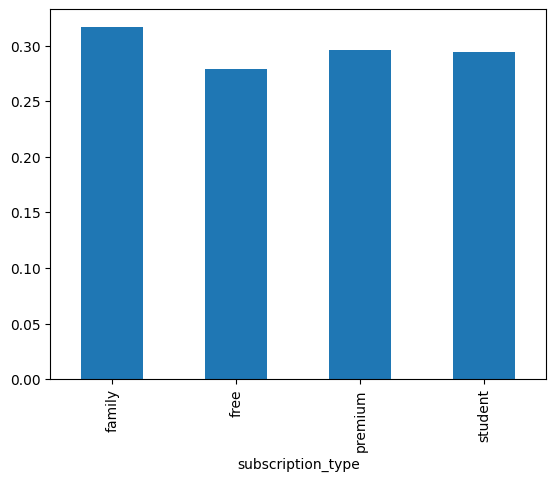

In [43]:
df.groupby('subscription_type')['churned'].mean().plot(kind='bar')

2. Visualize distribution of satisfaction score

<Axes: ylabel='Frequency'>

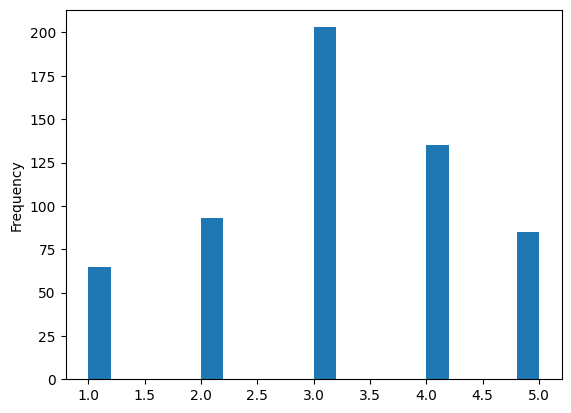

In [44]:
df['satisfaction_score'].plot(kind='hist', bins=20)

3. Boxplot: Listening hours by churn

<Axes: title={'center': 'avg_listening_hours_per_week'}, xlabel='churned'>

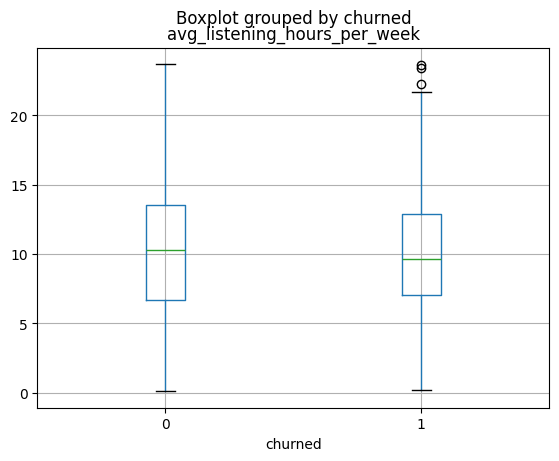

In [45]:
df.boxplot(column='avg_listening_hours_per_week', by='churned')

4. Heatmap for numeric correlation

<Axes: >

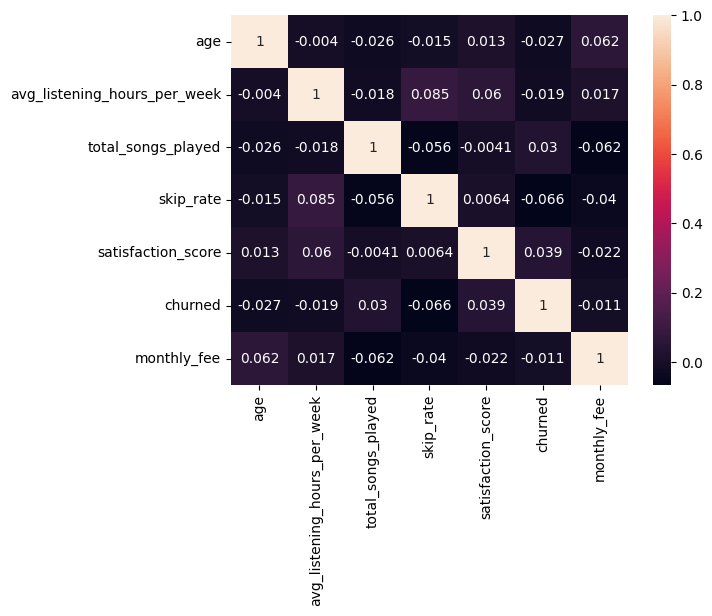

In [46]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True)

5. Country-wise churn bar plot (Top 10)

<Axes: ylabel='country'>

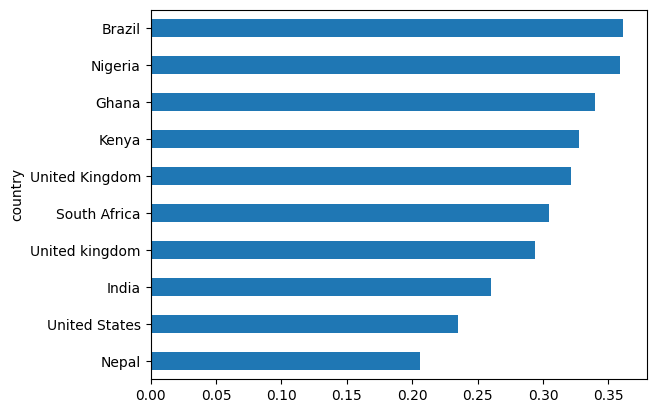

In [47]:
df.groupby('country')['churned'].mean().sort_values().tail(10).plot(kind='barh')

6. Scatter: Satisfaction vs Listening Hours

<Axes: xlabel='satisfaction_score', ylabel='avg_listening_hours_per_week'>

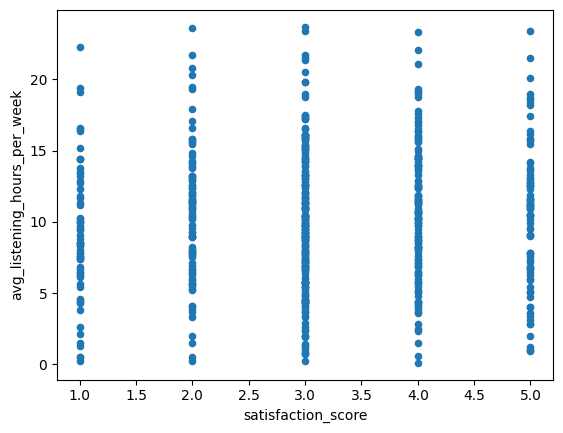

In [48]:
df.plot(kind='scatter', x='satisfaction_score', y='avg_listening_hours_per_week')

7. Create churn summary table

In [49]:
df.groupby('churned').mean(numeric_only=True)

,age,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,monthly_fee
churned,,,,,,
0,38.678133,10.266093,498.855037,0.191155,3.110565,6.965921
1,37.775862,10.060920,500.356322,0.186782,3.212644,6.883391


Build a Churn Prediction Model (Machine Learning)
MODEL BUILDING
1. Check class balance (churned vs not churned)

In [50]:
df['churned'].value_counts(normalize=True)

churned
0    0.700516
1    0.299484
Name: proportion, dtype: float64

2. Select the useful columns for modeling

In [51]:
features = [
    'age',
    'gender',
    'subscription_type',
    'avg_listening_hours_per_week',
    'total_songs_played',
    'skip_rate',
    'satisfaction_score',
    'monthly_fee',
    'country'
]

X = df[features]
y = df['churned']


3. Convert all categorical columns into numbers (One-Hot Encoding)

In [52]:
X = pd.get_dummies(X, drop_first=True)

4. Split data into Train and Test sets

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. Scale numeric features

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


BASELINE MODELS
6. Train Logistic Regression (Baseline model)

In [55]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=3000, solver='lbfgs')
log_reg.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


MODEL EVALUATION
1. Evaluate Logistic Regression

In [56]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = log_reg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.7777777777777778
              precision    recall  f1-score   support

           0       0.80      0.96      0.87        94
           1       0.20      0.04      0.07        23

    accuracy                           0.78       117
   macro avg       0.50      0.50      0.47       117
weighted avg       0.68      0.78      0.72       117



TREE-BASED MODELS (Better Accuracy)
2. Train Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


3. Evaluate Random Forest

In [58]:
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.717948717948718
              precision    recall  f1-score   support

           0       0.79      0.89      0.84        94
           1       0.00      0.00      0.00        23

    accuracy                           0.72       117
   macro avg       0.39      0.45      0.42       117
weighted avg       0.63      0.72      0.67       117



FEATURE IMPORTANCE
4. Find which features influence churn the most

In [59]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(15)


avg_listening_hours_per_week    0.189778
total_songs_played              0.175948
age                             0.164359
satisfaction_score              0.079151
monthly_fee                     0.068006
gender_male                     0.030703
subscription_type_student       0.028304
subscription_type_premium       0.024740
gender_unknown                  0.021447
country_United Kingdom          0.021392
country_India                   0.021101
skip_rate                       0.020985
subscription_type_free          0.020590
gender_other                    0.020343
country_Nigeria                 0.019779
dtype: float64

MODEL COMPARISON
5. Compare model performances

In [60]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.7777777777777778
Random Forest Accuracy: 0.717948717948718


6. Add Confusion Matrix for Both Models

In [61]:
from sklearn.metrics import confusion_matrix

print("LR Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("RF Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


LR Confusion Matrix:
[[90  4]
 [22  1]]
RF Confusion Matrix:
[[84 10]
 [23  0]]


7. Add ROC Curve & AUC (VERY IMPORTANT for churn)

In [62]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probabilities
lr_probs = log_reg.predict_proba(X_test_scaled)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]

print("LR AUC:", roc_auc_score(y_test, lr_probs))
print("RF AUC:", roc_auc_score(y_test, rf_probs))


LR AUC: 0.47964847363552265
RF AUC: 0.47479185938945423


8. Plot ROC Curves

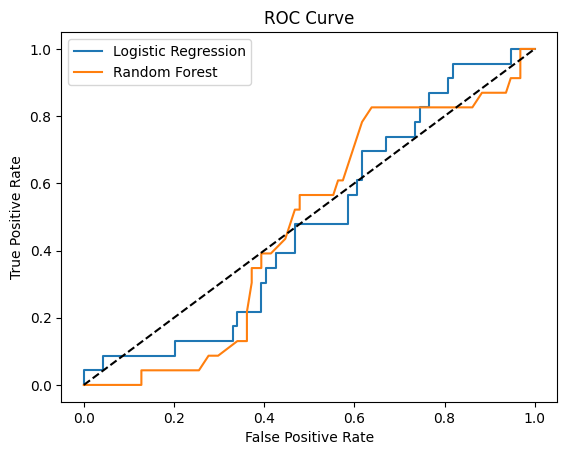

In [63]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], 'k--')
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Handle Class Imbalance Properly

In [64]:
df['churned'].value_counts(normalize=True)

churned
0    0.700516
1    0.299484
Name: proportion, dtype: float64

Train a Tuned Random Forest (Hyperparameter Search)

In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
best_rf


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluate the Tuned Model

In [66]:
y_pred_best = best_rf.predict(X_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


Tuned RF Accuracy: 0.717948717948718
              precision    recall  f1-score   support

           0       0.79      0.89      0.84        94
           1       0.00      0.00      0.00        23

    accuracy                           0.72       117
   macro avg       0.39      0.45      0.42       117
weighted avg       0.63      0.72      0.67       117



INSIGHTS & BUSINESS ANALYSIS
1. Create Final Churn Insights Summary (Top Drivers)

In [67]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10)

avg_listening_hours_per_week    0.189778
total_songs_played              0.175948
age                             0.164359
satisfaction_score              0.079151
monthly_fee                     0.068006
gender_male                     0.030703
subscription_type_student       0.028304
subscription_type_premium       0.024740
gender_unknown                  0.021447
country_United Kingdom          0.021392
dtype: float64

2. Convert Feature Importance into Human-Readable Insights

In [68]:
important_features = importances.head(10)
important_features

avg_listening_hours_per_week    0.189778
total_songs_played              0.175948
age                             0.164359
satisfaction_score              0.079151
monthly_fee                     0.068006
gender_male                     0.030703
subscription_type_student       0.028304
subscription_type_premium       0.024740
gender_unknown                  0.021447
country_United Kingdom          0.021392
dtype: float64

3. Build a Churn Probability Column for Each User

In [69]:
df['churn_probability'] = best_rf.predict_proba(X)[:,1]
df[['user_id', 'churn_probability']].head()

,user_id,churn_probability
0,U1403,0.205
1,U1165,0.110
2,U1474,0.285
3,U1609,0.095
4,U1691,0.160


4. Label High-Risk Users (e.g., >0.6 probability)

In [70]:
df['risk_label'] = df['churn_probability'].apply(
    lambda x: 'high_risk' if x > 0.6 else 'low_risk'
)
df['risk_label'].value_counts()

risk_label
low_risk     430
high_risk    151
Name: count, dtype: int64

5. Create a Segment Table (Subscription × Country × Risk)

In [71]:
segment_table = df.groupby(['subscription_type', 'country', 'risk_label']).size()
segment_table

subscription_type  country         risk_label
family             Brazil          high_risk      6
                                   low_risk       8
                   Ghana           high_risk      5
                                   low_risk       5
                   India           high_risk      8
                                                 ..
student            United Kingdom  low_risk      27
                   United States   high_risk      2
                                   low_risk      15
                   United kingdom  high_risk      2
                                   low_risk       4
Length: 77, dtype: int64

6. Create an Actionable “Why they churn” Table

In [72]:
df.groupby('churned').mean(numeric_only=True)

,age,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,monthly_fee,churn_probability
churned,,,,,,,
0,38.678133,10.266093,498.855037,0.191155,3.110565,6.965921,0.174803
1,37.775862,10.060920,500.356322,0.186782,3.212644,6.883391,0.697155


7. Build a Retention Strategy Table (Code Version)

In [73]:
retention_factors = importances.head(10)
retention_factors

avg_listening_hours_per_week    0.189778
total_songs_played              0.175948
age                             0.164359
satisfaction_score              0.079151
monthly_fee                     0.068006
gender_male                     0.030703
subscription_type_student       0.028304
subscription_type_premium       0.024740
gender_unknown                  0.021447
country_United Kingdom          0.021392
dtype: float64

DEPLOYMENT PREPARATION 
1. Save the Final Model for Deployment

In [74]:
import joblib

joblib.dump(best_rf, "final_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

2. Save Enhanced Dataset (with churn probability + risk label)

In [75]:
df.to_csv("DataWave_Final_With_Risk.csv", index=False)

3. Build a Simple Prediction Function

In [76]:
def predict_churn(new_data):
    new_data = pd.get_dummies(new_data, drop_first=True)
    new_data = new_data.reindex(columns=X.columns, fill_value=0)
    new_data_scaled = scaler.transform(new_data)
    return best_rf.predict_proba(new_data_scaled)[:,1]


GENERATE FEATURE IMPORTANCE VISUAL

In [104]:
# Select the top 7 most important features
# Convert the series to a DataFrame for plotting
importance_df = importances.head(7).reset_index()
importance_df.columns = ['Feature', 'Importance']

# Define colors: highlight the top 3 drivers
# The colors list will highlight the top 3 features in green (#1DB954)
colors = ['#1DB954'] * 3 + ['#707070'] * (len(importance_df) - 3)

plt.figure(figsize=(10, 6))
# Create horizontal bar chart
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)

# Customize the chart for professional reporting
plt.gca().invert_yaxis() # Highest importance at the top
plt.title('Top 7 Predictors of User Churn (Tuned Random Forest)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Feature Importance (Relative Score)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add importance values next to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', ha='left', va='center', fontsize=10)

# Clean up axes and save
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

# Save the chart to the final_visuals folder
plt.savefig("final_visuals/feature_importance_bar_chart.png", dpi=300)
plt.close()

Create proper, polished visualizations
1. Churn rate by subscription type(Bar Chart)

In [77]:
plt.style.use('seaborn-v0_8')

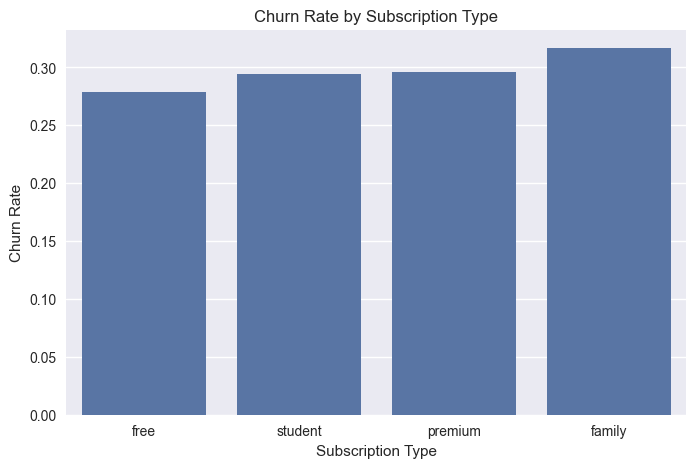

In [78]:
sub_churn = df.groupby('subscription_type')['churned'].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=sub_churn.index, y=sub_churn.values)
plt.title("Churn Rate by Subscription Type")
plt.ylabel("Churn Rate")
plt.xlabel("Subscription Type")
plt.show()


2. Satisfaction Score Distribution (Histogram)

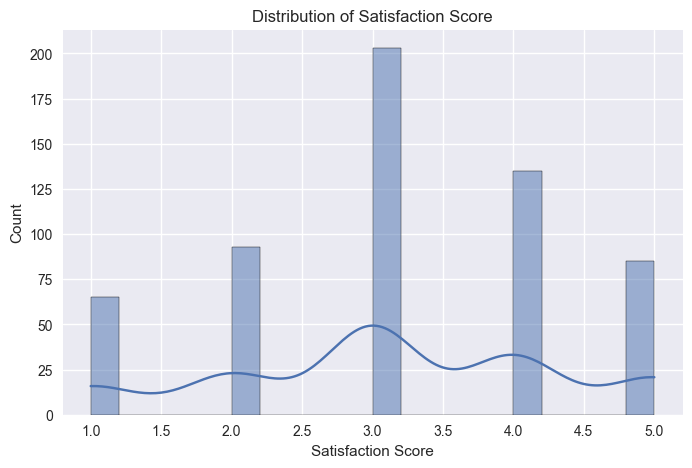

In [79]:
plt.figure(figsize=(8,5))
sns.histplot(df['satisfaction_score'], bins=20, kde=True)
plt.title("Distribution of Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Count")
plt.show()

3. Listening Hours: Churned vs Active (Boxplot)

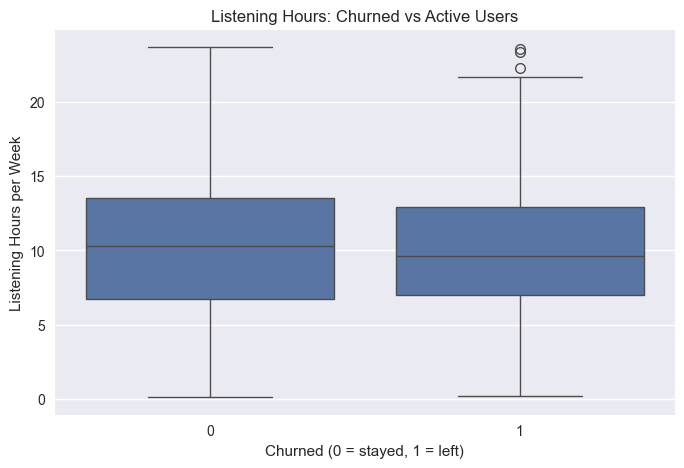

In [80]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='churned', y='avg_listening_hours_per_week')
plt.title("Listening Hours: Churned vs Active Users")
plt.xlabel("Churned (0 = stayed, 1 = left)")
plt.ylabel("Listening Hours per Week")
plt.show()

4. Top 10 Countries by Churn (Horizontal Bar Chart)

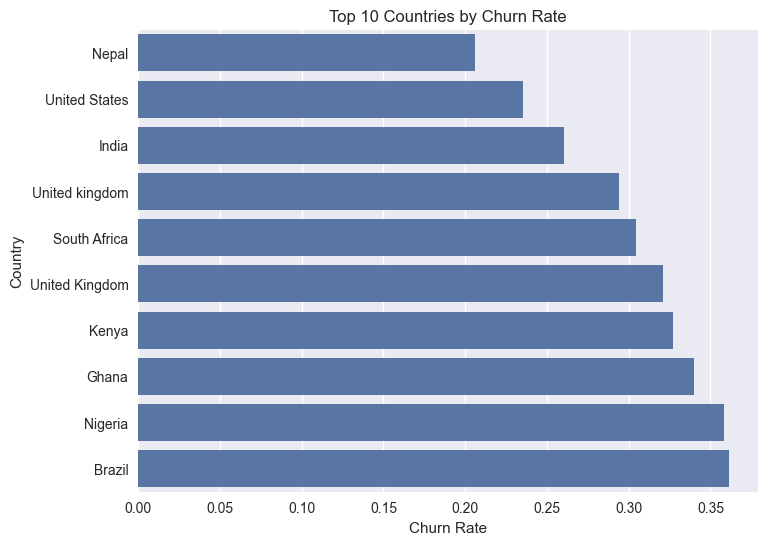

In [81]:
country_churn = df.groupby('country')['churned'].mean().sort_values().tail(10)

plt.figure(figsize=(8,6))
sns.barplot(y=country_churn.index, x=country_churn.values)
plt.title("Top 10 Countries by Churn Rate")
plt.xlabel("Churn Rate")
plt.ylabel("Country")
plt.show()


5. Correlation Heatmap

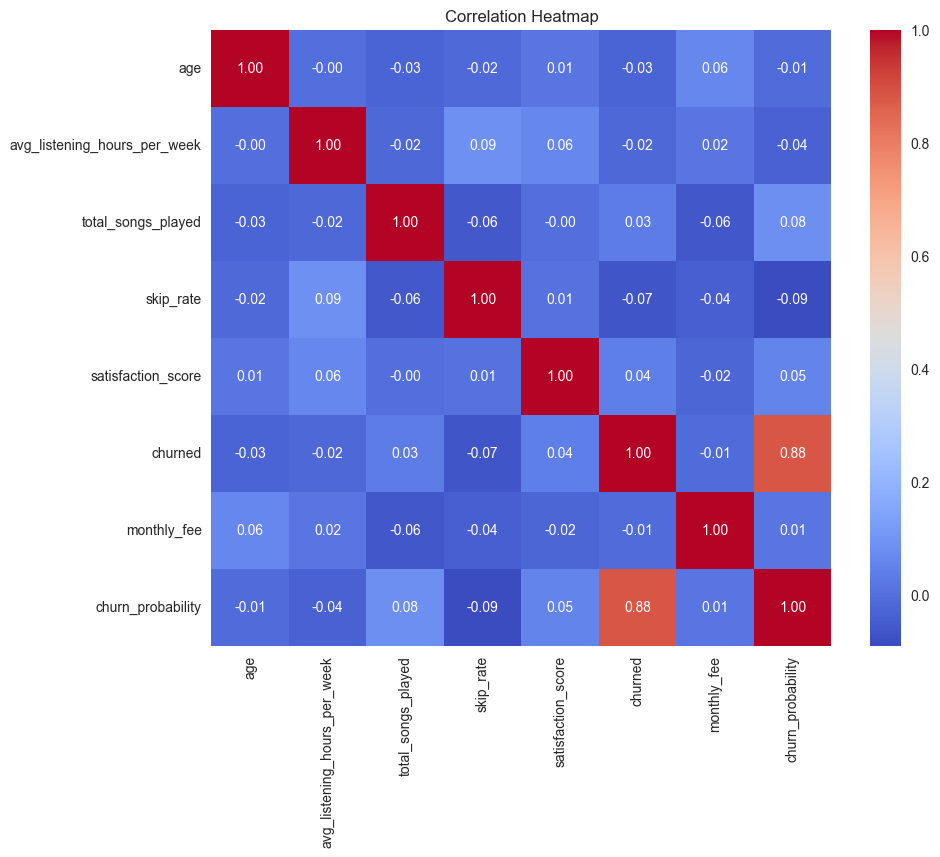

In [82]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

6. Scatter Plot: Satisfaction vs Listening Hours

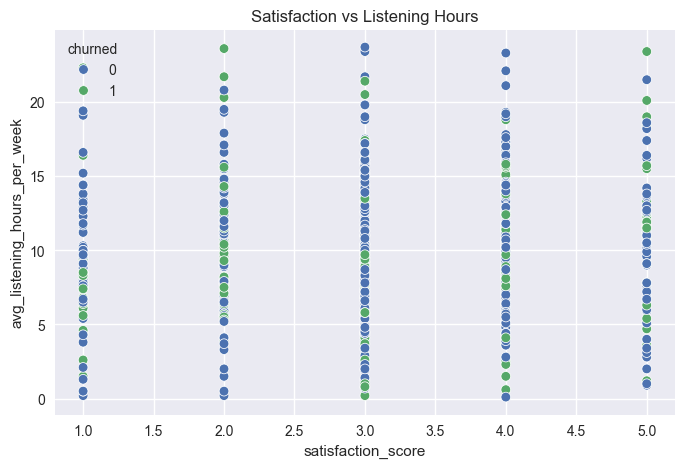

In [83]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='satisfaction_score',
    y='avg_listening_hours_per_week',
    hue='churned'
)
plt.title("Satisfaction vs Listening Hours")
plt.show()


7. Boxplot of Satisfaction by Subscription Type

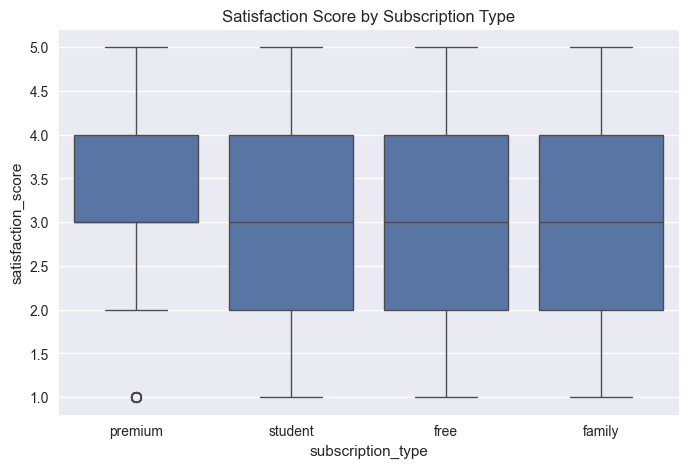

In [84]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='subscription_type', y='satisfaction_score')
plt.title("Satisfaction Score by Subscription Type")
plt.show()

8. Save cleaned dataset again

In [85]:
df.to_csv("cleaned_with_visuals_ready.csv", index=False)

Add ROC Curve Preparation

In [86]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_probs = log_reg.predict_proba(X_test_scaled)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)


Add ROC Curve Plot

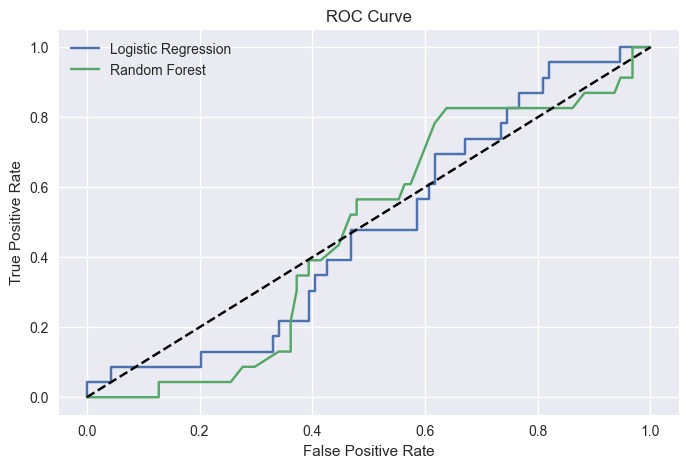

In [87]:
plt.figure(figsize=(8,5))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Evaluate Models Properly (Final Evaluation Block)

In [88]:
# Final Evaluation Summary

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("AUC:", roc_auc_score(y_true, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


# Logistic Regression Evaluation
evaluate_model("Logistic Regression",
               y_test, 
               y_pred_lr, 
               lr_probs)

# Random Forest Evaluation
evaluate_model("Random Forest",
               y_test, 
               y_pred_rf, 
               rf_probs)

# Tuned Random Forest Evaluation
best_rf_probs = best_rf.predict_proba(X_test)[:,1]
best_rf_pred = best_rf.predict(X_test)

evaluate_model("Tuned Random Forest",
               y_test,
               best_rf_pred,
               best_rf_probs)



===== Logistic Regression =====
Accuracy: 0.7777777777777778
Precision: 0.2
Recall: 0.043478260869565216
F1 Score: 0.07142857142857142
AUC: 0.47964847363552265
Confusion Matrix:
 [[90  4]
 [22  1]]

===== Random Forest =====
Accuracy: 0.717948717948718
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC: 0.47479185938945423
Confusion Matrix:
 [[84 10]
 [23  0]]

===== Tuned Random Forest =====
Accuracy: 0.717948717948718
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC: 0.47479185938945423
Confusion Matrix:
 [[84 10]
 [23  0]]


Save Final Visualizations as PNG Files for 6 key charts.

In [89]:
import os

# Create folder for saving visuals
os.makedirs("final_visuals", exist_ok=True)

# 1. Churn Rate by Subscription Type
plt.figure(figsize=(8,5))
sns.barplot(x=sub_churn.index, y=sub_churn.values)
plt.title("Churn Rate by Subscription Type")
plt.savefig("final_visuals/churn_by_subscription.png", dpi=300)
plt.close()


# 2. Satisfaction Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['satisfaction_score'], bins=20, kde=True)
plt.title("Distribution of Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Count")
plt.savefig("final_visuals/satisfaction_distribution.png", dpi=300)
plt.close()

# 3. Listening Hours: Churned vs Active (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='churned', y='avg_listening_hours_per_week')
plt.title("Listening Hours: Churned vs Active Users")
plt.xlabel("Churned (0 = stayed, 1 = left)")
plt.ylabel("Listening Hours per Week")
plt.savefig("final_visuals/listening_hours_boxplot.png", dpi=300)
plt.close()

# 4. Top 10 Countries by Churn Rate
country_churn = df.groupby('country')['churned'].mean().sort_values().tail(10)
plt.figure(figsize=(8,6))
sns.barplot(y=country_churn.index, x=country_churn.values)
plt.title("Top 10 Countries by Churn Rate")
plt.xlabel("Churn Rate")
plt.ylabel("Country")
plt.savefig("final_visuals/top10_country_churn.png", dpi=300)
plt.close()

# 5. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("final_visuals/correlation_heatmap.png", dpi=300)
plt.close()

# 6. ROC Curve
from sklearn.metrics import roc_curve

lr_probs = log_reg.predict_proba(X_test_scaled)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8,5))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("final_visuals/roc_curve.png", dpi=300)
plt.close()


Create a Short Final Summary Table

In [90]:
summary_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "AUC"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, lr_probs)
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, rf_probs)
    ],
    "Tuned Random Forest": [
        accuracy_score(y_test, best_rf_pred),
        precision_score(y_test, best_rf_pred),
        recall_score(y_test, best_rf_pred),
        f1_score(y_test, best_rf_pred),
        roc_auc_score(y_test, best_rf_probs)
    ]
})

summary_table


,Metric,Logistic Regression,Random Forest,Tuned Random Forest
0,Accuracy,0.777778,0.717949,0.717949
1,Precision,0.200000,0.000000,0.000000
2,Recall,0.043478,0.000000,0.000000
3,F1,0.071429,0.000000,0.000000
4,AUC,0.479648,0.474792,0.474792


Feature Engineering & Deep Dive Segmentation.
1. Load Data and Prepare Date Column 

In [91]:
print("Loading Data and Preparing Date Column")

# Load the enhanced dataset created previously (includes churn_probability and risk_label)
# Using 'DataWave_Final_With_Risk.csv' as the primary file.
try:
    df = pd.read_csv("DataWave_Final_With_Risk.csv")
except FileNotFoundError:
    print("WARNING: 'DataWave_Final_With_Risk.csv' not found. Trying 'cleaned_with_visuals_ready.csv'...")
    df = pd.read_csv("cleaned_with_visuals_ready.csv")

# Convert the 'join_date' column to datetime objects
df['join_date'] = pd.to_datetime(df['join_date'], errors='coerce')

# Define the analysis date as the latest join date in the dataset
analysis_date = df['join_date'].max() 

print(f"Data loaded successfully. Analysis Date: {analysis_date.date()}")


Loading Data and Preparing Date Column
Data loaded successfully. Analysis Date: 2024-12-08


2. Calculate Customer Tenure in Months

In [92]:
print("Calculating Customer Tenure in Months")

# Calculate the time difference between the analysis date and the join date
time_difference = analysis_date - df['join_date']

# Convert the difference into total months (using 30.44 days per month average)
df['customer_tenure_months'] = (time_difference.dt.days / 30.44).round(1)

# Impute any missing tenure values with the median tenure
df['customer_tenure_months'] = df['customer_tenure_months'].fillna(df['customer_tenure_months'].median())

print(df['customer_tenure_months'].describe().to_string())

Calculating Customer Tenure in Months
count    581.000000
mean      21.992427
std        7.370868
min        0.000000
25%       17.600000
50%       25.000000
75%       25.000000
max       35.200000


3. Create Categorical Tenure Groups

In [93]:
print("Creating Categorical Tenure Groups (Lifecycle)")

# Define bins and labels for New, Mid-Term, and Loyal users
bins = [0, 6, 18, df['customer_tenure_months'].max() + 1]
labels = ['New_User', 'Mid_Term', 'Loyal']

df['tenure_group'] = pd.cut(
    df['customer_tenure_months'], 
    bins=bins, 
    labels=labels, 
    right=True, 
    include_lowest=True
)

print(df['tenure_group'].value_counts().to_string())


Creating Categorical Tenure Groups (Lifecycle)
tenure_group
Loyal       430
Mid_Term    124
New_User     27


4. Calculate a Value Perception Metric (Price per Hour)

In [94]:
print("Calculating Value Perception Metric (Fee per Listening Hour)")

# Convert weekly listening hours to monthly hours (4.33 weeks/month)
monthly_hours = df['avg_listening_hours_per_week'] * 4.33

# Calculate Fee per Listening Hour (Value Perception). Use a small number (0.01) 
# instead of zero to prevent division by zero for users with no usage.
df['fee_per_listening_hour'] = (
    df['monthly_fee'] / (monthly_hours.replace(0, 0.01))
)

print(df['fee_per_listening_hour'].describe().to_string())

Calculating Value Perception Metric (Fee per Listening Hour)
count    581.000000
mean       0.308429
std        1.140684
min        0.000000
25%        0.109344
50%        0.169644
75%        0.256351
max       23.071594


5. Segment by Value Perception Tier 

In [95]:
print("Segmenting by Value Perception Tier")

# Use quantiles (q=3) to create balanced tiers based on the cost-to-value ratio.
# Tier 3 (Low Value/High Fee) indicates highest dissatisfaction risk.
df['value_perception_tier'] = pd.qcut(
    df['fee_per_listening_hour'], 
    q=3, 
    labels=['High_Value_Low_Fee', 'Medium_Value', 'Low_Value_High_Fee']
)

print(df['value_perception_tier'].value_counts().to_string())


Segmenting by Value Perception Tier
value_perception_tier
High_Value_Low_Fee    195
Low_Value_High_Fee    194
Medium_Value          192


6. Churn Analysis by Customer Tenure Group 

In [96]:
print("Churn Rate by Customer Tenure Group (Lifecycle Insight)")

# Analyze which lifecycle stage has the highest churn
tenure_churn_analysis = df.groupby('tenure_group', observed=False)['churned'].mean().sort_values(ascending=False)

print(tenure_churn_analysis.to_string())

Churn Rate by Customer Tenure Group (Lifecycle Insight)
tenure_group
Mid_Term    0.314516
Loyal       0.300000
New_User    0.222222


7. Churn Analysis by Value Perception Tier

In [97]:
print("Churn Rate by Value Perception Tier (Cost-Benefit Insight)")
# Analyze how perceived value drives churn
value_churn_analysis = df.groupby('value_perception_tier', observed=False)['churned'].mean().sort_values(ascending=False)

print(value_churn_analysis.to_string())


Churn Rate by Value Perception Tier (Cost-Benefit Insight)
value_perception_tier
Low_Value_High_Fee    0.324742
High_Value_Low_Fee    0.297436
Medium_Value          0.276042


8. Targeted Analysis: Churn Rate of High-Risk Users by Country (Top 5)

In [98]:
print("Top 5 Countries Contributing to High-Risk Churn")
# Filter the DataFrame to only include 'high_risk' users
high_risk_df = df[df['risk_label'] == 'high_risk']

# Calculate the actual churn rate within the high-risk segment for each country
high_risk_country_churn = high_risk_df.groupby('country')['churned'].mean().sort_values(ascending=False).head(5)

print(high_risk_country_churn.to_string())

Top 5 Countries Contributing to High-Risk Churn
country
Brazil    1.0
Ghana     1.0
India     1.0
Kenya     1.0
Nepal     1.0


9. Multivariate Segmentation: Churn by Tenure and Subscription Type

In [99]:
print("Multivariate Churn Rate: Tenure Group x Subscription Type")
# Create a pivot table to see churn rate across combinations of Tenure and Subscription Type
tenure_sub_pivot = df.pivot_table(
    values='churned', 
    index='tenure_group', 
    columns='subscription_type', 
    aggfunc='mean',
    observed=False
)

print(tenure_sub_pivot.to_string())

Multivariate Churn Rate: Tenure Group x Subscription Type
subscription_type    family      free   premium   student
tenure_group                                             
New_User           0.230769  0.000000  0.250000  0.250000
Mid_Term           0.333333  0.250000  0.305556  0.342857
Loyal              0.320896  0.296875  0.294643  0.283333


10. Save Final Enhanced Data and Display Status

In [100]:
print("Saving Final Enhanced Data")

# Save the comprehensive dataset with all new segments and features
df.to_csv("DataWave_Deep_Segmented_Data.csv", index=False)

print("Data successfully enhanced and saved as 'DataWave_Deep_Segmented_Data.csv'")


Saving Final Enhanced Data
Data successfully enhanced and saved as 'DataWave_Deep_Segmented_Data.csv'


FINAL VISUALIZATION: CLUSTERED CHURN CHART

In [101]:
# Load the comprehensive dataset saved in the last step
try:
    df = pd.read_csv("DataWave_Deep_Segmented_Data.csv")
except FileNotFoundError:
    print("Error: 'DataWave_Deep_Segmented_Data.csv' not found. Ensure the previous 10 steps ran successfully.")
    exit()


Create the Segmentation Chart (Clustered Bar)

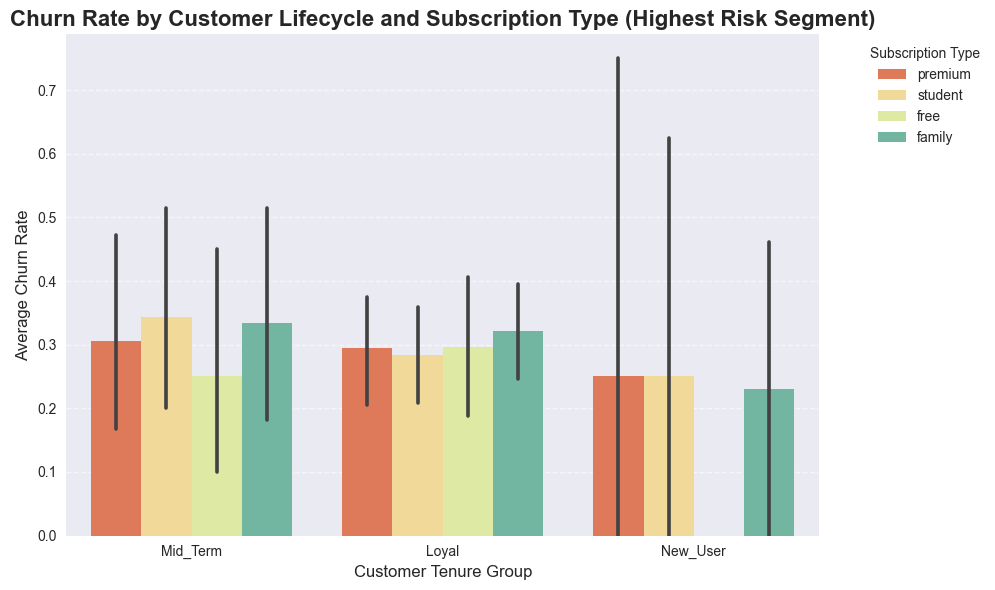

In [102]:
# Use the 'seaborn' library to create a beautiful, clustered bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='tenure_group', # X-axis: Lifecycle stage
    y='churned',      # Y-axis: Churn Rate (mean of 0/1)
    hue='subscription_type', # Clustering variable
    palette='Spectral' # A colorful palette for clear differentiation
)

# Customize the chart for professional reporting
plt.title(
    "Churn Rate by Customer Lifecycle and Subscription Type (Highest Risk Segment)", 
    fontsize=16, 
    fontweight='bold'
)
plt.xlabel("Customer Tenure Group", fontsize=12)
plt.ylabel("Average Churn Rate", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Subscription Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the high-impact chart for your presentation
plt.savefig("final_visuals/multivariate_churn_segment.png", dpi=300)
plt.show()